# Implement Gradient Descent Algorithm for Multiple Linear Regression

## Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import data

In [2]:
data = pd.read_csv("auto_mpg.csv")

In [3]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


**Explanation of the Data**

This data tabulates "miles per gallon (mpg)" of different cars with different number of cylinders, displacement, power of the engine (in hp), weight of the car (in kg), accelaration of the car, model_year

For our exercise we shall choose the explanatory variables / predictors:

- displacement
- horsepower
- weight
- accelaration

All of these variables are quantitative in nature.

and our target variable is: mpg

In [4]:
data.shape

(398, 9)

So we have 398 datapoints. 



In [5]:
# We are going to predict the miles per gallon (mpg) of a car based on its features. The features we are going to use are:

features = ['displacement', 'horsepower', 'weight', 'acceleration'] # Independent varaibles
target = ['mpg'] # target / response / dependent variable

## Data Preprocessing

In [6]:
data[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   horsepower    398 non-null    object 
 2   weight        398 non-null    float64
 3   acceleration  398 non-null    float64
dtypes: float64(3), object(1)
memory usage: 12.6+ KB


In [7]:
data[data['horsepower']=='?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car_name
32,25.0,4,98.0,?,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035.0,20.5,82,1,amc concord dl


### drop the rows where horsepower is '?'

In [8]:
data = data.drop(data[data['horsepower']=='?'].index).reset_index(drop=True)

In [9]:
data['horsepower'] = data['horsepower'].values.astype('float')

In [10]:
data[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  392 non-null    float64
 1   horsepower    392 non-null    float64
 2   weight        392 non-null    float64
 3   acceleration  392 non-null    float64
dtypes: float64(4)
memory usage: 12.4 KB


## Choose X and y

In [11]:
X = data[features].values
y = data[target].values

### Split the data into train and test

Install `scikit-learn` package using `pip install scikit-learn` in your virtual environment


In [12]:
from sklearn.model_selection import train_test_split

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7) # 70% training and 30% test

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=500) # 500 training data and rest test data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25) # 25% test data and rest 75% training data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200) # 200 test data and rest training data
```

We will consider 300 randomly chosen datapoints as our training samples and rest of the data as test samples (92).

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=300, random_state=42)  

In [14]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((300, 4), (300, 1), (92, 4), (92, 1))

## Univariate analysis

### displacement

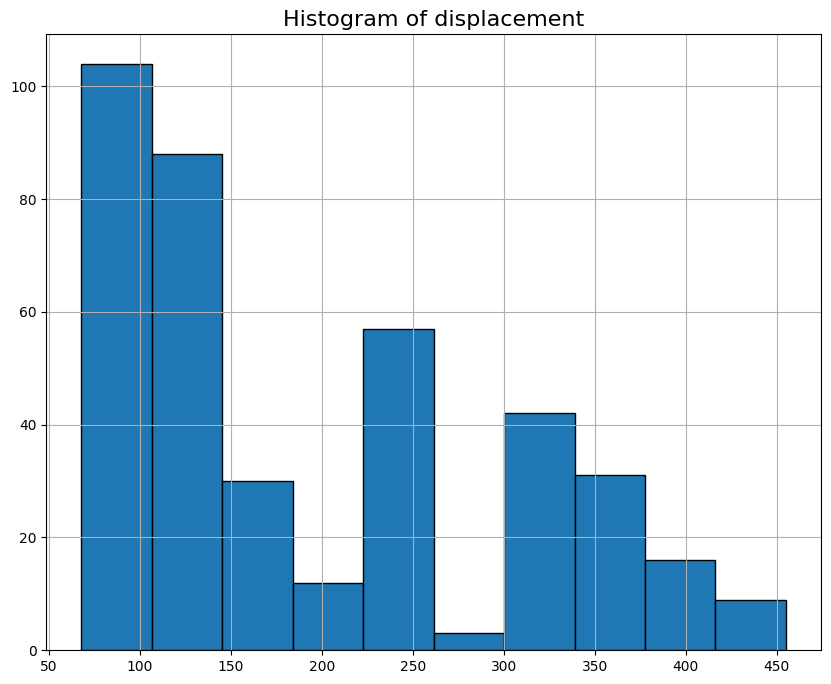

In [15]:
plt.figure(figsize=(10,8))
plt.hist(data['displacement'], edgecolor='k')
plt.grid()
plt.title("Histogram of displacement", fontsize=16)
plt.show()

### horsepower

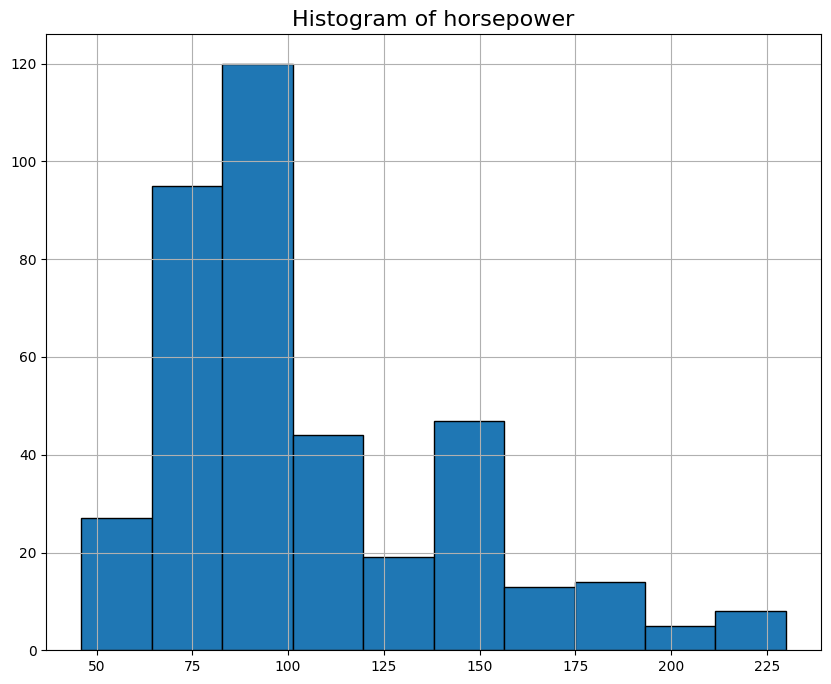

In [16]:
plt.figure(figsize=(10,8))
plt.hist(data['horsepower'], edgecolor='k')
plt.grid()
plt.title("Histogram of horsepower", fontsize=16)
plt.show()

### weight

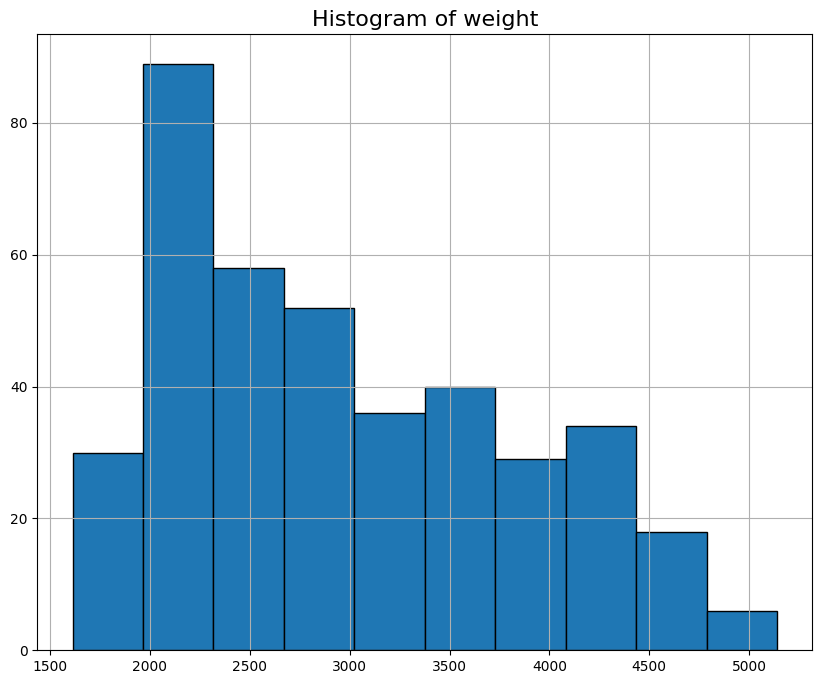

In [17]:
plt.figure(figsize=(10,8))
plt.hist(data['weight'], edgecolor='k')
plt.grid()
plt.title("Histogram of weight", fontsize=16)
plt.show()

### acceleration

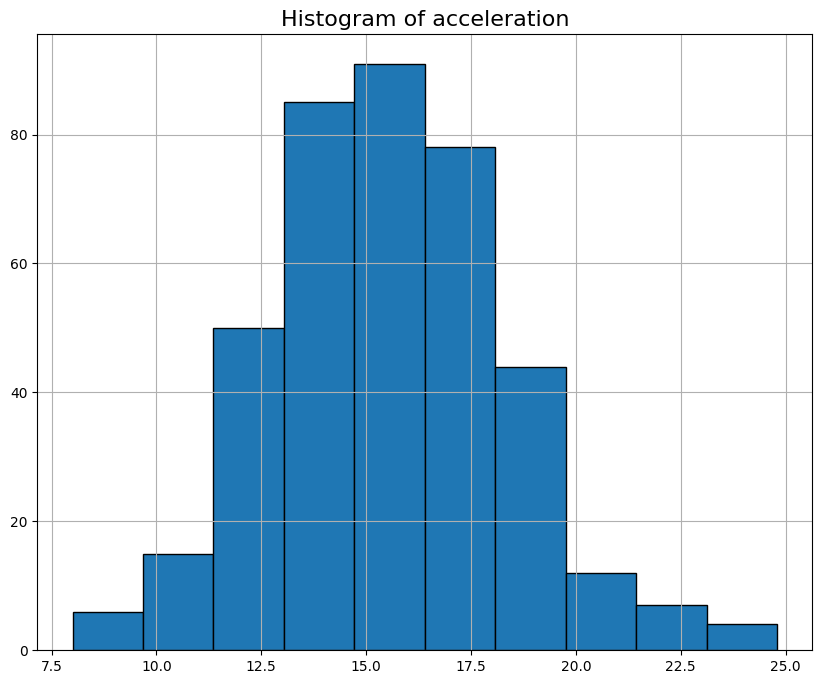

In [18]:
plt.figure(figsize=(10,8))
plt.hist(data['acceleration'], edgecolor='k')
plt.grid()
plt.title("Histogram of acceleration", fontsize=16)
plt.show()

### mpg

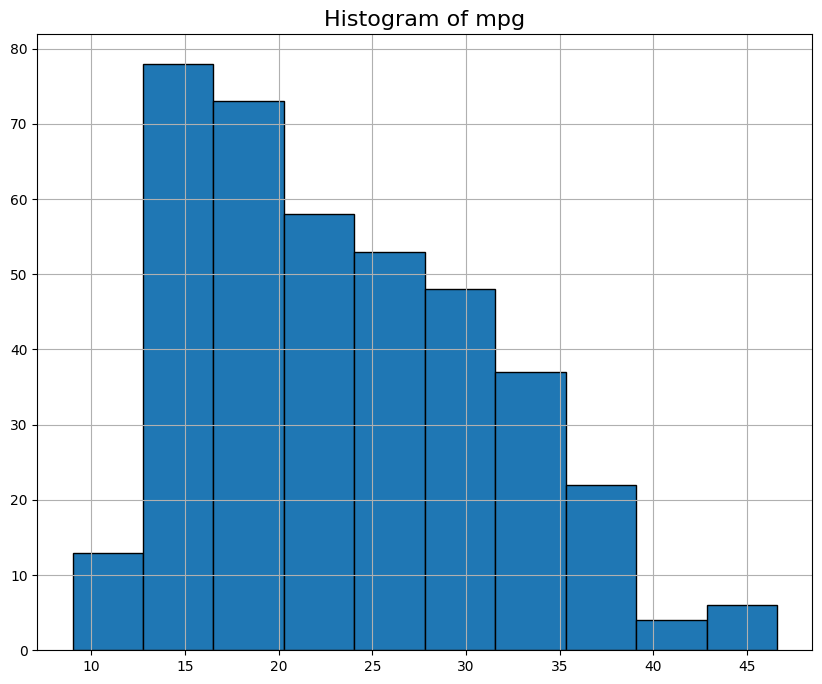

In [43]:
plt.figure(figsize=(10,8))
plt.hist(data['mpg'], edgecolor='k')
plt.grid()
plt.title("Histogram of mpg", fontsize=16)
plt.show()

### Bivaraite analysis using pair-plot

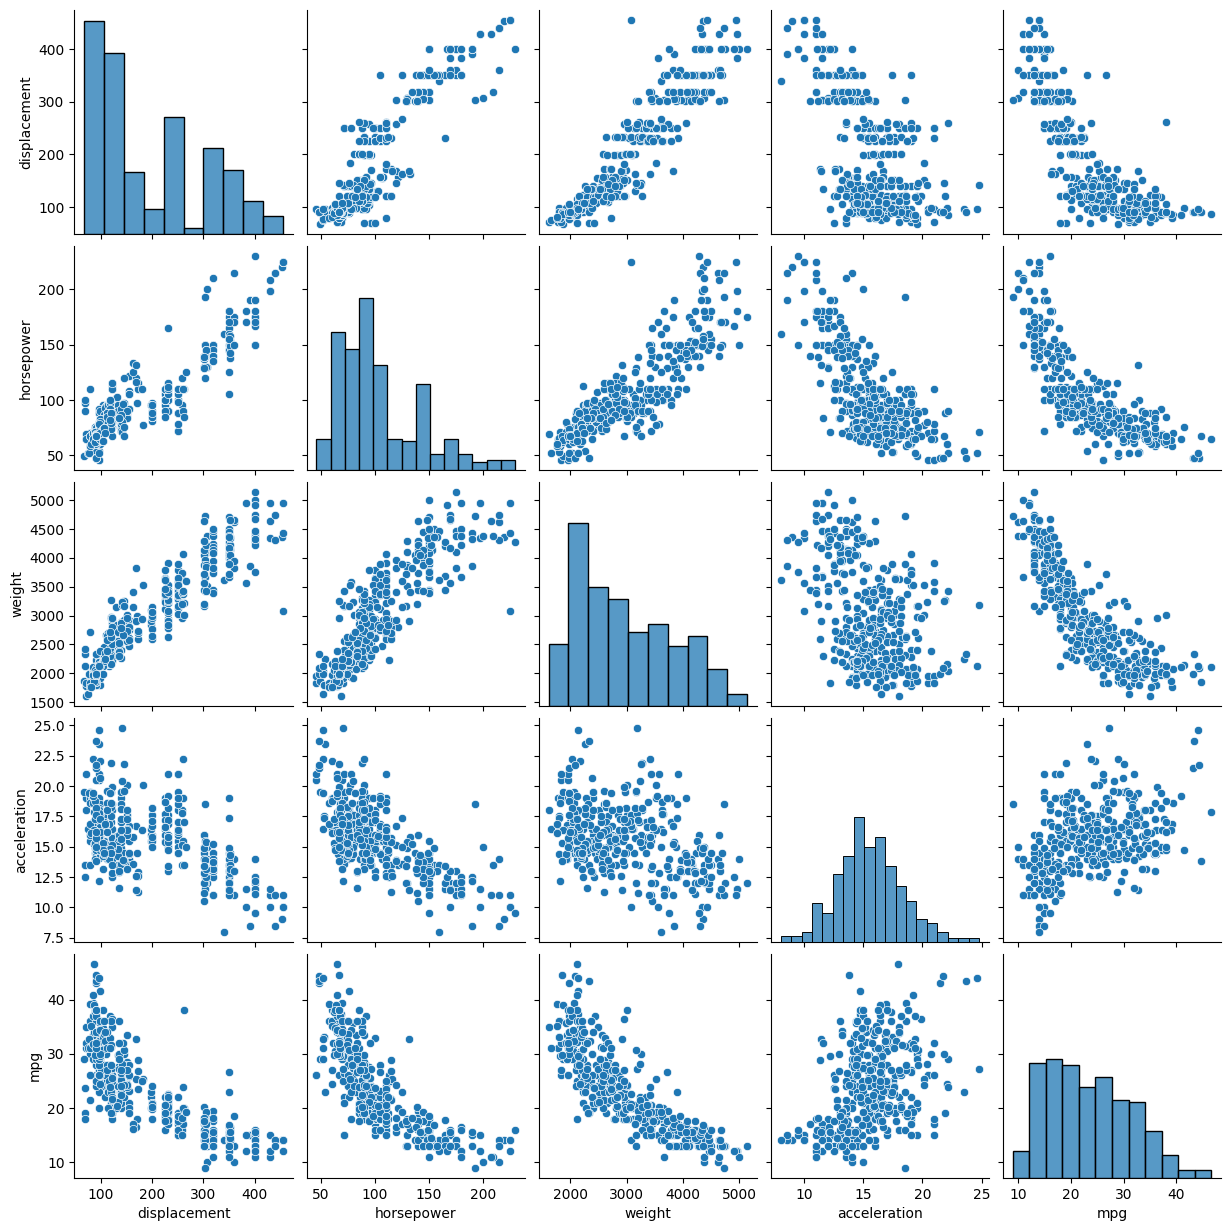

In [44]:
import seaborn as sns

sns.pairplot(data[features + target])

In [46]:
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
389,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
390,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [49]:
features

['displacement', 'horsepower', 'weight', 'acceleration']

In [48]:
np.corrcoef(data[features+target].values.T)

array([[ 1.        ,  0.897257  ,  0.9329944 , -0.5438005 , -0.80512695],
       [ 0.897257  ,  1.        ,  0.86453774, -0.68919551, -0.77842678],
       [ 0.9329944 ,  0.86453774,  1.        , -0.4168392 , -0.83224421],
       [-0.5438005 , -0.68919551, -0.4168392 ,  1.        ,  0.42332854],
       [-0.80512695, -0.77842678, -0.83224421,  0.42332854,  1.        ]])

## Feature Scaling

For gradient descent to work better we need features to be within same scale. 

We need to perform feature scaling in order to make gradient descent work better.

We will use min-max scaling.

$$x_j = \frac{x_j - x_j^{min}}{x_j^{max} - x_j^{min}}$$

In [19]:
X_train.shape[1]

4

In [ ]:
for i in range(X_train.shape[1]):
    # minimum and maximum of the feature in the training set
    minimum = X_train[:,i].min()
    maximum = X_train[:,i].max()

    # Use the minimum and maximum of the feature in the training set to normalize both the training and test set
    X_train[:,i] = (X_train[:,i] - minimum)/(maximum - minimum)
    X_test[:,i] = (X_test[:,i] - minimum)/(maximum - minimum)

In [21]:
X_train[0:5]

array([[0.07012987, 0.11413043, 0.10547207, 0.5       ],
       [0.10909091, 0.21195652, 0.27275305, 0.48809524],
       [0.41818182, 0.32065217, 0.54493904, 0.66666667],
       [0.25454545, 0.40217391, 0.62574426, 0.51785714],
       [0.13246753, 0.35869565, 0.37425574, 0.38690476]])

In [22]:
X_test[0:5]

array([[0.06753247, 0.125     , 0.1633116 , 0.5952381 ],
       [0.13246753, 0.375     , 0.335129  , 0.45833333],
       [0.05454545, 0.07608696, 0.05301956, 0.5       ],
       [0.05454545, 0.13043478, 0.09696626, 0.74404762],
       [0.18181818, 0.2173913 , 0.33371137, 0.45238095]])

## Gradient Descent Algorithm

### Step-1: initialize model parameters with random values

We will have k+1 model parameters if we have k features

In [23]:
features

['displacement', 'horsepower', 'weight', 'acceleration']

In [24]:
k = len(features)

In [25]:
theta = np.random.rand(k+1)

In [26]:
theta

array([8.90481161e-01, 6.59793553e-01, 7.80865595e-04, 7.77749777e-01,
       2.85176281e-01])

### Step-2: add $x_0$ with all 1

In [27]:
x_0_train = np.ones(shape=X_train.shape[0])

In [28]:
x_0_train

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [29]:
x_0_train.shape

(300,)

In [30]:
X_train = np.hstack((x_0_train.reshape(-1,1), X_train))

In [33]:
x_0_test = np.ones(shape=X_test.shape[0])
X_test = np.hstack((x_0_test.reshape(-1,1), X_test))

In [32]:
X_train.shape

(300, 5)

In [31]:
X_train[0:5]

array([[1.        , 0.07012987, 0.11413043, 0.10547207, 0.5       ],
       [1.        , 0.10909091, 0.21195652, 0.27275305, 0.48809524],
       [1.        , 0.41818182, 0.32065217, 0.54493904, 0.66666667],
       [1.        , 0.25454545, 0.40217391, 0.62574426, 0.51785714],
       [1.        , 0.13246753, 0.35869565, 0.37425574, 0.38690476]])

In [34]:
X_test.shape

(92, 5)

In [35]:
X_test[0:5]

array([[1.        , 0.06753247, 0.125     , 0.1633116 , 0.5952381 ],
       [1.        , 0.13246753, 0.375     , 0.335129  , 0.45833333],
       [1.        , 0.05454545, 0.07608696, 0.05301956, 0.5       ],
       [1.        , 0.05454545, 0.13043478, 0.09696626, 0.74404762],
       [1.        , 0.18181818, 0.2173913 , 0.33371137, 0.45238095]])

### Step-3: Create a function that predicts the target variable

$$\hat{y} = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + .... + \theta_k x_k$$

$$\hat{y} = \sum_{i=0}^{k} \theta_i x_i$$

In [36]:
theta.reshape(1,-1).shape

(1, 5)

In [37]:
def predict(params, X):
    return (X @ params.reshape(-1,1))

In [38]:
y_pred = predict(theta, X_train)

In [40]:
y_pred[0:5]

array([[1.16146054],
       [1.31395096],
       [1.78058895],
       [1.69309569],
       [1.37957586]])

In [41]:
y_train[0:5]

array([[30. ],
       [31. ],
       [19.2],
       [16.5],
       [18. ]])

In [39]:
y_pred.shape, y_train.shape, X_train.shape, theta.shape

((300, 1), (300, 1), (300, 5), (5,))

### Step-4: Mean Square Error (MSE) Cost function 

$$ J = \frac{1}{2m} \sum_{i=1}^{m} (y_{pred} - y_{actual})^2$$

In [50]:
def cost_function(y_pred, y_actual):
    errors = y_pred - y_actual
    return np.square(errors).sum()/(2*y_pred.shape[0])

### Step-5: Gradient descent update rule

$$ \hat{\theta_j}(t+1) \leftarrow \hat{\theta_j}(t) - \frac{\alpha}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) x_j^{(i)} $$

In [88]:
def gradient_descent_linear_reg(X_values, y_values, theta_init, iterations = 1000, alpha = 0.01, alpha_scaling = False, tolerance = 0.0001):
    """
    inputs:
    -------
    X_values : training samples of features
    y_values : values of target varaible
    theta_init : initial values of model parameters
    tolerance : the minimum change in theta required
    iterations : total number of iterations
    alpha : learning rate
    alpha_scaling : moderate the value of learning rate
    
    output:
    -------
    theta : optimized model parameter
    cost_values : list of cost values
    """
    cost_values = []                      # starting with an empty list, will append the value of the cost function in each iteration.
    theta = theta_init                    # initializing the theta 
    it = 0                                # start with the iteration count = 0
    m = X_values.shape[0]                 # m = number of data / samples
    alpha_max = alpha                     # maximum value of learning rate
    alpha_min = alpha/100                 # minimum value of learning rate (will be used, if we use alpha scaling)
    
    #-------- Gradient descent algorithm -----------#

    while(it < iterations):                                 # Using max iteration stopping criteria inside a while loop
        y_pred = predict(theta, X_values)                   # Predicted value of the target variable
        cost = cost_function(y_pred, y_values)              # Calculate the cost function given predicted and actual values
        cost_values.append(cost)
        
        # alpha scaling
        if alpha_scaling:
            alpha = alpha_max - ((alpha_max - alpha_min)/(iterations))*it
        
        # gradient descent update rule
        del_theta = ((-1*alpha / m) * (X_values.T @ (y_pred - y_values)).flatten())
        theta = theta + del_theta

        it += 1                     # incrementing iteration count by 1

        # stopping criteria
        del_theta_mag = np.linalg.norm(del_theta)
        if del_theta_mag < tolerance:
            break
        
    return theta, cost_values, it

In [89]:
model_params, costs, max_it = gradient_descent_linear_reg(X_train, y_train, theta, iterations=10000, alpha=0.01, tolerance=1e-4, alpha_scaling=False)

In [90]:
model_params

array([ 31.4151391 ,  -9.10435045,  -3.55498533, -13.72785741,
         3.56403471])

In [91]:
max_it

10000

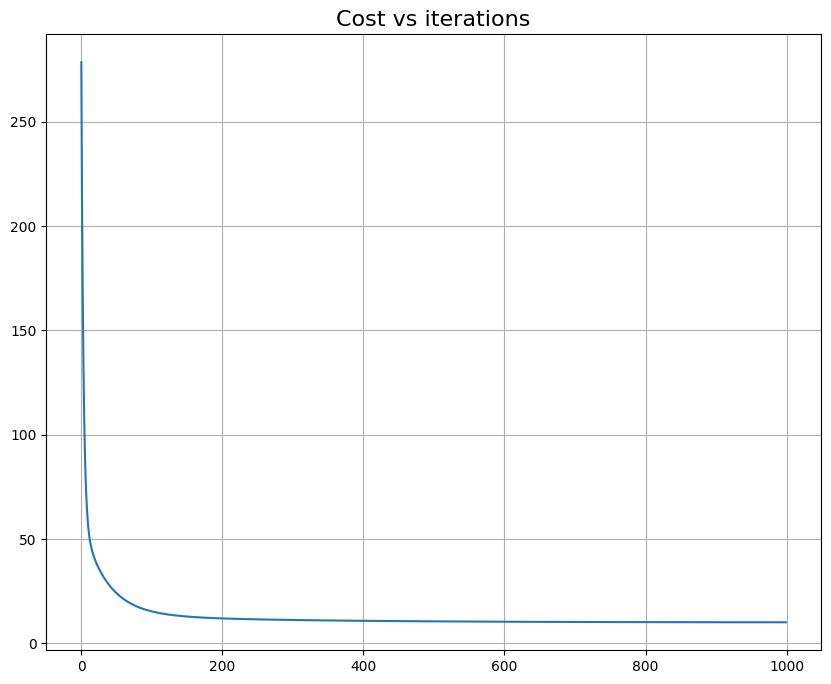

In [68]:
plt.figure(figsize=(10,8))
plt.plot(costs)
plt.grid()
plt.title("Cost vs iterations", fontsize=16)
plt.show()

## Evaluation

### On the training dataset

In [92]:
model_output = predict(model_params, X_train)

In [93]:
pd.DataFrame(np.hstack((model_output, y_train, model_output-y_train)), columns=['Predicted values', 'Actual values', 'Errors'])

,Predicted values,Actual values,Errors
0,30.705032,30.0,0.705032
1,27.663708,31.0,-3.336292
2,21.363129,19.2,2.163129
3,20.923479,16.5,4.423479
4,25.175163,18.0,7.175163
...,...,...,...
295,15.956531,15.0,0.956531
296,23.448671,18.0,5.448671
297,25.948631,23.8,2.148631
298,30.094822,29.9,0.194822


In [94]:
cost_function(model_output, y_train).item()

9.364017529152358

### Evaluation on test dataset

In [95]:
model_output = predict(model_params, X_test)

In [96]:
pd.DataFrame(np.hstack((model_output, y_test, model_output-y_test)), columns=['Predicted values', 'Actual values', 'Errors'])

,Predicted values,Actual values,Errors
0,30.235458,26.0,4.235458
1,25.908901,21.6,4.308901
2,31.702223,36.1,-4.397777
3,31.775517,26.0,5.775517
4,26.018139,27.0,-0.981861
...,...,...,...
87,21.492516,21.5,-0.007484
88,18.494900,17.0,1.494900
89,19.586222,16.0,3.586222
90,25.950922,22.3,3.650922


In [97]:
cost_function(model_output, y_test).item()

8.894062084875326

## Using sklearn library to perform linear regression

`pip install scikit-learn` in your virtual environment.

In [75]:
from sklearn.linear_model import LinearRegression

In [76]:
model = LinearRegression(tol=1e-4)

In [77]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",0.0001
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
model.fit(X_train[:,1:], y_train)   # training the model  (x_0 column is not required)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",0.0001
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### evaluation

In [79]:
y_pred_train = model.predict(X_train[:,1:])

In [80]:
pd.DataFrame(np.hstack((y_pred_train, y_train, y_pred_train-y_train)), columns=['Predicted values', 'Actual values', 'Errors'])

,Predicted values,Actual values,Errors
0,31.318300,30.0,1.318300
1,27.388333,31.0,-3.611667
2,20.226528,19.2,1.026528
3,18.922896,16.5,2.422896
4,24.307783,18.0,6.307783
...,...,...,...
295,16.025300,15.0,1.025300
296,24.474055,18.0,6.474055
297,25.513682,23.8,1.713682
298,29.106820,29.9,-0.793180


In [81]:
cost_function(y_pred_train, y_train).item()

9.029445186068308

In [82]:
y_pred_test = model.predict(X_test[:,1:])

In [83]:
pd.DataFrame(np.hstack((y_pred_test, y_test, y_pred_test-y_test)), columns=['Predicted values', 'Actual values', 'Errors'])

,Predicted values,Actual values,Errors
0,30.089528,26.0,4.089528
1,24.708556,21.6,3.108556
2,32.640320,36.1,-3.459680
3,30.990535,26.0,4.990535
4,26.069669,27.0,-0.930331
...,...,...,...
87,21.455101,21.5,-0.044899
88,17.151369,17.0,0.151369
89,19.308955,16.0,3.308955
90,25.325044,22.3,3.025044


In [84]:
cost_function(y_pred_test, y_test).item()

8.779670034422804

In [85]:
model.intercept_   # optimized theta_0 value

array([35.25938268])

In [86]:
model.coef_        # optimized rest of the model parameters

array([[ -3.86059718,  -9.63312118, -17.07024772,  -1.54094627]])

In [98]:
model_params # model parameters obtained from our gradient descent implementation

array([ 31.4151391 ,  -9.10435045,  -3.55498533, -13.72785741,
         3.56403471])

### Normal Equation

The normal equation is the way to solve the optimum parameters of the linear regression model in closed form.

$$ \hat{\Theta} = (X^TX)^{-1}X^Ty $$

In [99]:
X = X_train.copy()
y = y_train.copy()

In [100]:
theta_optimized = np.linalg.inv(X.T @ X) @ X.T @ y    # normal equation in numpy

theta_optimized

array([[ 35.25938268],
       [ -3.86059718],
       [ -9.63312118],
       [-17.07024772],
       [ -1.54094627]])

In [101]:
model.intercept_, model.coef_

(array([35.25938268]),
 array([[ -3.86059718,  -9.63312118, -17.07024772,  -1.54094627]]))

In [102]:
y_pred_train = predict(theta_optimized.flatten(), X_train)

cost_function(y_pred_train, y_train).item()

9.029445186068306

In [103]:
y_pred_test = predict(theta_optimized.flatten(), X_test)

cost_function(y_pred_test, y_test).item()

8.77967003442261